# Подготовка модели распознавания рукописных букв и цифр

In [12]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import (
    Compose,
    ToTensor,
    Normalize,
    Lambda
)
from torchvision.transforms import functional as TF
from torchinfo import summary
from torchvision import datasets
import matplotlib.pyplot as plt


dataset = datasets.EMNIST('data/', split='balanced', download=False)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
Path("models").mkdir(exist_ok=True)

In [13]:
mapping_path = Path('data/EMNIST/raw/emnist-balanced-mapping.txt')

mapping = {}

with open(mapping_path, 'r') as file:
    for line in file:
        label, ascii_code = map(int, line.split())
        mapping[label] = chr(ascii_code)

print(mapping)
print(len(mapping))

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z', 36: 'a', 37: 'b', 38: 'd', 39: 'e', 40: 'f', 41: 'g', 42: 'h', 43: 'n', 44: 'q', 45: 'r', 46: 't'}
47


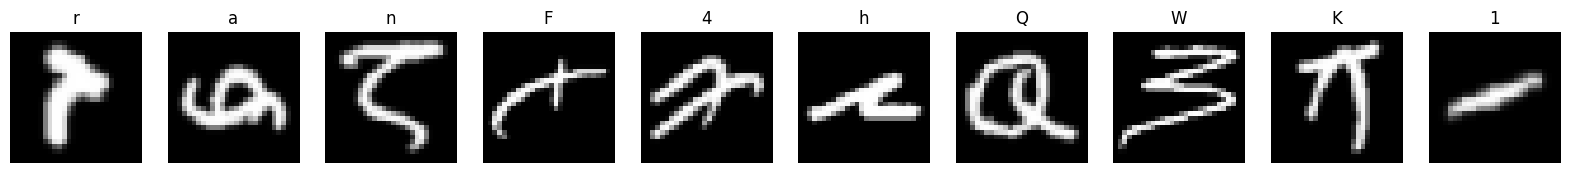

In [14]:
fig, axs = plt.subplots(1, 10, figsize=(20, 5))
for i in range(10):
    axs[i].imshow(dataset[i][0], cmap='gray')
    axs[i].set_title(mapping[dataset[i][1]])
    axs[i].axis('off')
plt.show()

In [15]:
transform = Compose([
    Lambda(lambda img: TF.hflip(
        TF.rotate(img, -90)
    )),
    ToTensor(),
    Normalize([0.5], [0.5])
])

full_train_dataset = datasets.EMNIST(
    'data/',
    split='balanced',
    download=False,
    transform=transform,
    train=True
)

test_dataset = datasets.EMNIST(
    'data/',
    split='balanced',
    download=False,
    transform=transform,
    train=False
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1000,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1000
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000
)

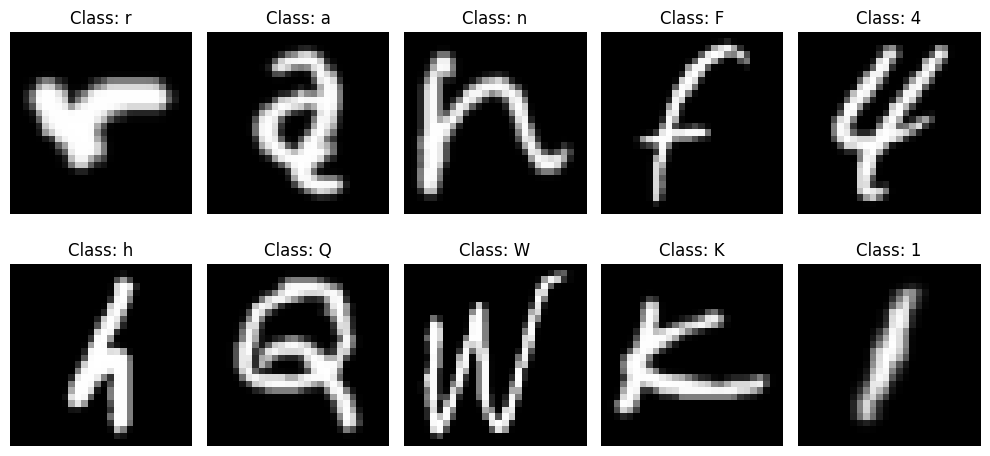

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = full_train_dataset[i]

    # tensor (1, 28, 28) -> (28, 28)
    image = image.squeeze()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Class: {mapping[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
class DigitCNN(nn.Module):
    def __init__(
        self,
        channels=(16, 32),
        hidden_size=64,
        dropout=0.0,
        num_classes=47
    ):
        super().__init__()

        feature_layers = []

        in_channels = 1
        image_size = 28

        for out_channels in channels:
            feature_layers.extend([
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    padding=1
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2)
            ])

            in_channels = out_channels
            image_size //= 2

        self.features = nn.Sequential(*feature_layers)

        flattened_size = (
            in_channels * image_size * image_size
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [18]:
def train(
    model,
    optimizer,
    loss_f,
    train_loader,
    val_loader,
    n_epoch,
    val_fre,
    config
):
    best_val_loss = float("inf")
    patience = 3
    checks_without_improvement = 0

    for epoch in range(n_epoch):
        model.train()
        loss_sum = 0

        print(f"Epoch: {epoch + 1}/{n_epoch}")

        for step, (data, target) in enumerate(train_loader):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()

            output = model(data)
            loss = loss_f(output, target)

            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        mean_train_loss = loss_sum / len(train_loader)

        print(f"Mean Train Loss: {mean_train_loss:.6f}")

        if (epoch + 1) % val_fre == 0:
            val_loss = validate(model, val_loader, loss_f)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                checks_without_improvement = 0

                torch.save({
                        "model_state_dict": model.state_dict(),
                        "config": config,
                        "val_loss": best_val_loss
                    }, f"models/{config['name']}.pt")

                print("Сохранена новая лучшая модель")

            else:
                checks_without_improvement += 1

                print(
                    "Нет улучшения:",
                    checks_without_improvement,
                    "из",
                    patience
                )

                if checks_without_improvement >= patience:
                    print("Ранняя остановка обучения")
                    break


def validate(model, val_loader, loss_f):
    model.eval()

    loss_sum = 0
    correct = 0

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)
            
            output = model(data)
            loss = loss_f(output, target)

            loss_sum += loss.item()

            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()

    val_loss = loss_sum / len(val_loader)
    accuracy = correct / len(val_loader.dataset)

    print(
        f"Val Loss: {val_loss:.6f} "
        f"\tAccuracy: {accuracy * 100:.2f}%"
    )

    return val_loss


In [19]:
experiments = [
    {
        "name": "baseline",
        "channels": (16, 32),
        "hidden_size": 64,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0
    },
    {
        "name": "with_dropout",
        "channels": (16, 32),
        "hidden_size": 64,
        "dropout": 0.3,
        "learning_rate": 0.001,
        "weight_decay": 0.0
    },
    {
        "name": "more_channels",
        "channels": (32, 64),
        "hidden_size": 64,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0
    },
    {
        "name": "three_conv_layers",
        "channels": (16, 32, 64),
        "hidden_size": 64,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0
    },
    {
        "name": "with_weight_decay",
        "channels": (16, 32),
        "hidden_size": 64,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 1e-4
    }
]

In [20]:
for config in experiments:
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    print("=" * 60)
    print(f"Experiment: {config['name']}")
    print("=" * 60)

    model = DigitCNN(
        channels=config["channels"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"]
    ).to(device)

    loss_f = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    train(
        model=model,
        optimizer=optimizer,
        loss_f=loss_f,
        train_loader=train_loader,
        val_loader=val_loader,
        n_epoch=30,
        val_fre=1,
        config=config
    )

Experiment: baseline
Epoch: 1/30
Mean Train Loss: 1.570744
Val Loss: 0.739555 	Accuracy: 77.84%
Сохранена новая лучшая модель
Epoch: 2/30
Mean Train Loss: 0.610298
Val Loss: 0.558072 	Accuracy: 82.23%
Сохранена новая лучшая модель
Epoch: 3/30
Mean Train Loss: 0.507638
Val Loss: 0.491111 	Accuracy: 84.19%
Сохранена новая лучшая модель
Epoch: 4/30
Mean Train Loss: 0.460041
Val Loss: 0.474543 	Accuracy: 84.64%
Сохранена новая лучшая модель
Epoch: 5/30
Mean Train Loss: 0.431645
Val Loss: 0.443043 	Accuracy: 85.50%
Сохранена новая лучшая модель
Epoch: 6/30
Mean Train Loss: 0.406431
Val Loss: 0.449148 	Accuracy: 85.24%
Нет улучшения: 1 из 3
Epoch: 7/30
Mean Train Loss: 0.387744
Val Loss: 0.434614 	Accuracy: 85.51%
Сохранена новая лучшая модель
Epoch: 8/30
Mean Train Loss: 0.374030
Val Loss: 0.426636 	Accuracy: 85.93%
Сохранена новая лучшая модель
Epoch: 9/30
Mean Train Loss: 0.360476
Val Loss: 0.412043 	Accuracy: 86.56%
Сохранена новая лучшая модель
Epoch: 10/30
Mean Train Loss: 0.348976
Val

In [21]:
best_name = None
best_val_loss = float("inf")
best_checkpoint = None

for config in experiments:
    checkpoint = torch.load(
        f"models/{config['name']}.pt",
        map_location=device
    )

    if checkpoint["val_loss"] < best_val_loss:
        best_val_loss = checkpoint["val_loss"]
        best_name = config["name"]
        best_checkpoint = checkpoint

print("Best model:", best_name)
print("Best val loss:", best_val_loss)

Best model: three_conv_layers
Best val loss: 0.3614391995512921


In [22]:
config = best_checkpoint["config"]

model = DigitCNN(
    channels=config["channels"],
    hidden_size=config["hidden_size"],
    dropout=config["dropout"]
).to(device)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

loss_f = nn.CrossEntropyLoss()

print("Final test:")
validate(model, test_loader, loss_f)

Final test:
Val Loss: 0.374743 	Accuracy: 87.11%


0.3747430161425942

In [23]:
torch.save({
    "model_state_dict": best_checkpoint["model_state_dict"],
    "config": best_checkpoint["config"],
    "val_loss": best_checkpoint["val_loss"]
}, "myapp\\model.ckpt")